# BAI 2: ME CUNG - TIM DUONG DI TU 0 DEN A

Bai toan: Tim duong di tu diem bat dau (0) den diem ket thuc (A) trong me cung
- Su dung thuat toan BFS va DFS
- Me cung 5 hang x 4 cot
- 0 = duong di, 1 = tuong

## Import thu vien

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [2]:
from collections import deque
import sys

## Dinh nghia lop MazeProblem

In [3]:
class MazeProblem:
    def __init__(self):
        # 0 = duong di
        # 1 = tuong
        # 0 = diem bat dau (goc tren-trai)
        # A = diem ket thuc (goc duoi-phai)
        self.rows = 6
        self.cols = 6
        self.start = (0, 0)      
        self.goal = (5, 5)

        self.v_walls = [
            [0, 1, 0, 0, 0], 
            [0, 1, 0, 0, 0], 
            [0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0], 
            [0, 1, 0, 0, 0]  
        ]
        self.h_walls = [
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1], # Tường chặn ở hàng 2 xuống hàng 3 (cột 4,5)
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0]
        ]
    
    def get_neighbors(self, pos):
        """Lay cac vi tri lan can hop le"""
        r, c = pos
        neighbors = []
        
        # 1. Đi LÊN (Up) -> Giảm row. Kiểm tra tường ngang phía trên (h_walls[r-1])
        if r > 0 and self.h_walls[r-1][c] == 0:
            neighbors.append((r - 1, c))
            
        # 2. Đi XUỐNG (Down) -> Tăng row. Kiểm tra tường ngang phía dưới (h_walls[r])
        if r < self.rows - 1 and self.h_walls[r][c] == 0:
            neighbors.append((r + 1, c))
            
        # 3. Đi TRÁI (Left) -> Giảm col. Kiểm tra tường dọc bên trái (v_walls[c-1])
        if c > 0 and self.v_walls[r][c-1] == 0:
            neighbors.append((r, c - 1))
            
        # 4. Đi PHẢI (Right) -> Tăng col. Kiểm tra tường dọc bên phải (v_walls[c])
        if c < self.cols - 1 and self.v_walls[r][c] == 0:
            neighbors.append((r, c + 1))
            
        return neighbors
    
    def print_maze(self, path=None):
        """Vẽ mê cung dạng lưới ASCII đẹp mắt"""
        path_set = set(path) if path else set()
        
        print("\n MÊ CUNG 6x6 (Kết quả):")
        
        # Vẽ cạnh trên cùng
        print("  " + "+---" * self.cols + "+")
        
        for r in range(self.rows):
            # Dòng chứa nội dung ô và tường dọc
            line_content = "  |" # Bắt đầu bằng viền trái
            for c in range(self.cols):
                # Nội dung ô: S (start), E (end), ● (đường đi), hoặc khoảng trắng
                symbol = "   "
                if (r, c) == self.start:
                    symbol = " S "
                elif (r, c) == self.goal:
                    symbol = " E "
                elif (r, c) in path_set:
                    symbol = " ● " # Ký tự đường đi
                
                line_content += symbol
                
                # Vẽ tường dọc bên phải ô này?
                if c < self.cols - 1:
                    if self.v_walls[r][c] == 1:
                        line_content += "|" # Có tường
                    else:
                        line_content += " " # Thông nhau
            
            line_content += "|" # Viền phải cuối cùng
            print(line_content)
            
            # Dòng chứa tường ngang bên dưới
            if r < self.rows - 1: # Không vẽ dưới dòng cuối cùng (để vẽ đáy riêng)
                line_seperator = "  +"
                for c in range(self.cols):
                    if self.h_walls[r][c] == 1:
                        line_seperator += "---+" # Có tường ngang
                    else:
                        line_seperator += "   +" # Thông nhau
                print(line_seperator)
        
        # Vẽ cạnh đáy dưới cùng
        print("  " + "+---" * self.cols + "+")
        print("  Chú thích: S=Start, E=End, ●=Đường đi, |=Tường dọc, ---=Tường ngang\n")

## Thuat toan BFS

In [4]:
def bfs_maze(problem):
    """Tim duong di ngan nhat trong me cung bang BFS"""
    queue = deque([(problem.start, [problem.start])])
    visited = {problem.start}
    
    while queue:
        current, path = queue.popleft()
        
        # Kiem tra da den dich chua
        if current == problem.goal:
            return path
        
        for neighbor in problem.get_neighbors(current):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    return None

## Vẽ mê cung đồ họa

In [5]:
def draw_maze_graphic(problem, path=None):
    """Vẽ mê cung ra hình ảnh đồ họa thực tế (Chỉ hiển thị dấu chấm)"""
    fig, ax = plt.subplots(figsize=(6, 6)) # Tạo khung hình vuông
    
    rows = problem.rows
    cols = problem.cols
    
    # --- 1. VẼ KHUNG BAO NGOÀI ---
    ax.plot([0, cols, cols, 0, 0], [0, 0, rows, rows, 0], 'k-', linewidth=2)
    
    # --- 2. VẼ TƯỜNG BÊN TRONG ---
    # Vẽ lưới mờ
    for r in range(rows):
        ax.plot([0, cols], [r, r], 'gray', linewidth=0.5, alpha=0.3)
    for c in range(cols):
        ax.plot([c, c], [0, rows], 'gray', linewidth=0.5, alpha=0.3)

    # Vẽ Tường Dọc
    for r in range(rows):
        for c in range(cols - 1):
            if problem.v_walls[r][c] == 1:
                ax.plot([c + 1, c + 1], [r, r + 1], 'k-', linewidth=4)
                
    # Vẽ Tường Ngang
    for r in range(rows - 1):
        for c in range(cols):
            if problem.h_walls[r][c] == 1:
                ax.plot([c, c + 1], [r + 1, r + 1], 'k-', linewidth=4)
                
    # --- 3. VẼ ĐƯỜNG ĐI ---
    if path:
        y_coords = [p[0] + 0.5 for p in path]
        x_coords = [p[1] + 0.5 for p in path]
        
        # Vẽ đường nối màu đỏ
        ax.plot(x_coords, y_coords, 'r-', linewidth=3, alpha=0.7, label='Đường đi')
        # Vẽ các chấm tròn tại mỗi bước chân (Bao gồm cả điểm đầu)
        ax.scatter(x_coords, y_coords, c='red', s=100)

    # --- 4. VẼ ĐIỂM ĐẦU VÀ CUỐI ---
    
    # Vẽ chữ A tại đích (Nếu bạn muốn xóa luôn chữ A thì xóa 2 dòng dưới này nhé)
    end_r, end_c = problem.goal
    ax.text(end_c + 0.5, end_r + 0.5, 'A', ha='center', va='center', fontsize=20, fontweight='bold', color='blue')

    # --- CẤU HÌNH HIỂN THỊ ---
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.axis('off')
    plt.title("Kết quả Mê Cung", fontsize=14)
    plt.show()

## Chay chuong trinh

Đã tìm thấy đường đi: 10 bước

 MÊ CUNG 6x6 (Kết quả):
  +---+---+---+---+---+---+
  | S     |               |
  +   +   +   +   +   +   +
  | ●     |               |
  +   +   +   +   +   +   +
  | ●                     |
  +   +   +   +   +---+---+
  | ●   ●   ●             |
  +   +   +   +   +   +   +
  |       | ●             |
  +   +   +   +   +   +   +
  |       | ●   ●   ●   E |
  +---+---+---+---+---+---+
  Chú thích: S=Start, E=End, ●=Đường đi, |=Tường dọc, ---=Tường ngang



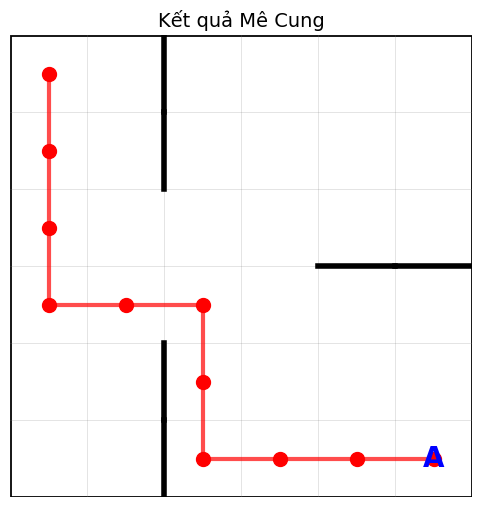

In [6]:
# --- CHẠY THỬ ---
problem = MazeProblem()
bfs_path = bfs_maze(problem)

if bfs_path:
    print(f"Đã tìm thấy đường đi: {len(bfs_path)-1} bước")
    problem.print_maze(bfs_path)
    draw_maze_graphic(problem, bfs_path)
else:
    print("Không tìm thấy đường đi!")